In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image

In [11]:
base_path = "../data/ChestXray_Classification/ChestXray_Classification"

train_dir = os.path.join(base_path, "train")
valid_dir = os.path.join(base_path, "valid")
test_dir = os.path.join(base_path, "test")

print(os.listdir(base_path))
print(os.listdir(train_dir))

['test', 'train', 'valid']
['0', '1']


In [12]:
class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(
            clipLimit=clip_limit,
            tileGridSize=tile_grid_size
        )

    def __call__(self, img):
        img = np.array(img.convert("L"))
        img = self.clahe.apply(img)
        img = Image.fromarray(img)
        return img

In [13]:
train_transforms = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(7),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

valid_test_transforms = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [14]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=valid_test_transforms)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))
print("Test size:", len(test_dataset))

Classes: ['0', '1']
Class mapping: {'0': 0, '1': 1}
Train size: 8554
Valid size: 1070
Test size: 1070


In [15]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Train batches: 268
Valid batches: 34
Test batches: 34


In [16]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 1, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([1, 1, 0, 0, 1, 1, 0, 1, 0, 0])


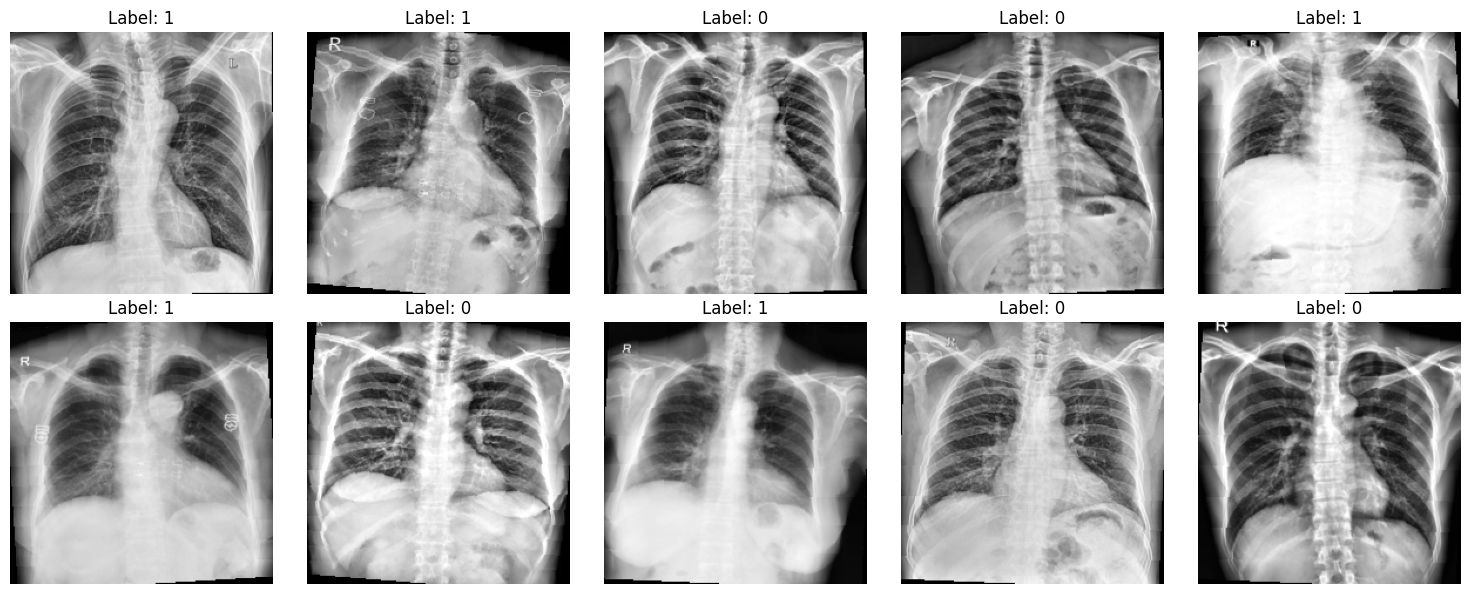

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(15,6))

for i in range(10):
    
    img = images[i].squeeze().numpy()
    
    axes[i//5, i%5].imshow(img, cmap='gray')
    axes[i//5, i%5].set_title(f"Label: {labels[i].item()}")
    axes[i//5, i%5].axis("off")

plt.tight_layout()
plt.show()

In [18]:
train_transforms = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(7),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])